# Etapa 6: Modelo de Classificação e Métricas

**Projeto Integrador (P15):** Previsão de Alta Demanda de Produtos da Bioeconomia Amazônica
Disciplina Banco de Dados e Engenharia de Dados para IA, Prof. Adolfo Colares, [UNIFAP – Universidade Federal do Amapá](https://www.unifap.br/)
Autor: Leonam Souza dos Santos Azevedo

**Pergunta de negócio:** no início de cada mês, um município terá **alta demanda** de açaí, castanha-do-pará ou óleo de copaíba, em relação ao seu próprio histórico? A resposta ajuda cooperativas e comerciantes a planejar estoque, compra e transporte, reduzindo falta de produto e desperdício de itens perecíveis como o açaí.

**Metodologia**

- **Dados:** base de modelagem `ml.features_demanda` (Etapa 5), com 16 features calculadas só com informação até o mês anterior.
- **Treino em 2023 e teste em 2024:** o teste é usado uma única vez, na avaliação final. Nenhuma escolha olha para ele.
- **Seleção por validação temporal dentro de 2023:** janela crescente (treina até junho e valida em julho e agosto; até agosto, valida em setembro e outubro; até outubro, valida em novembro e dezembro). Os hiperparâmetros e o modelo final são escolhidos pela média do F1 nessa validação.
- **Referências sem aprendizado:** "repetir o resultado do mês anterior" e "época de safra (índice sazonal > 1)". O modelo só se justifica se superar essas regras.
- **Modelos:** regressão logística (referência interpretável), Random Forest e Gradient Boosting (HistGradientBoosting).

**Métricas:** o alvo é equilibrado (cerca de 50% de alta demanda), então a **Accuracy** é informativa. O **F1** é a métrica principal, porque combina precisão (quando o modelo prevê alta demanda, quanto acerta) e recall (quanto das altas demandas reais ele encontra). A **AUC** mede a qualidade da ordenação das probabilidades, independentemente do limiar de 0,5.

**Roteiro**

1. Carga da base
2. Validação temporal
3. Treinamento e seleção de hiperparâmetros
4. Comparação no teste de 2024
5. Modelo final: matriz de confusão e curva ROC
6. Desempenho por produto e por mês
7. Importância das features
8. De onde vem o ganho do modelo
9. Modelo salvo e reprodutibilidade
10. Conclusões

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve

from src import config
from src.features import ALVO, FEATURES
from src.modelagem import (
    carregar_base_modelagem, carregar_modelo, importancia_permutacao, metricas_por_grupo,
    salvar_modelo, separar, folds_temporais, tabela_previsoes, treinar_e_avaliar,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_colwidth", None)

MESES = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
FIGURAS = config.REPORTS_DIR / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

def salvar(fig, nome):
    fig.savefig(FIGURAS / f"{nome}.png", bbox_inches="tight", dpi=150)

## 1. Carga da base

In [2]:
df, origem = carregar_base_modelagem()
treino, teste = separar(df)
print(f"Fonte: {origem}")
print(f"Treino (2023): {len(treino):,} registros | alta demanda: {treino[ALVO].mean():.1%}")
print(f"Teste  (2024): {len(teste):,} registros | alta demanda: {teste[ALVO].mean():.1%}")
print(f"Features: {len(FEATURES)}")

Fonte: PostgreSQL (ml.features_demanda)
Treino (2023): 7,992 registros | alta demanda: 50.2%
Teste  (2024): 7,990 registros | alta demanda: 49.1%
Features: 16


## 2. Validação temporal

In [3]:
folds = folds_temporais(treino)
pd.DataFrame(
    [
        {
            "etapa": i + 1,
            "treina com": f"{MESES[treino.loc[t, 'mes'].min() - 1]} a {MESES[treino.loc[t, 'mes'].max() - 1]}/2023",
            "valida em": f"{MESES[treino.loc[v, 'mes'].min() - 1]} e {MESES[treino.loc[v, 'mes'].max() - 1]}/2023",
            "registros de treino": len(t),
            "registros de validação": len(v),
        }
        for i, (t, v) in enumerate(folds)
    ]
)

,etapa,treina com,valida em,registros de treino,registros de validação
0,1,jan a jun/2023,jul e ago/2023,3996,1332
1,2,jan a ago/2023,set e out/2023,5328,1332
2,3,jan a out/2023,nov e dez/2023,6660,1332


Cada etapa treina com o passado e valida nos meses seguintes, como na divisão final entre 2023 e 2024. Uma validação cruzada comum, com embaralhamento, misturaria meses futuros no treino e produziria métricas otimistas.

## 3. Treinamento e seleção de hiperparâmetros

In [4]:
%%time
saida = treinar_e_avaliar(df)
resultados = saida["resultados"]
melhor = saida["melhor"]
print(f"Modelo final escolhido pela validação temporal: {melhor}")

Modelo final escolhido pela validação temporal: Regressão logística
CPU times: total: 1min 23s
Wall time: 13.7 s


In [5]:
busca_detalhada = []
for nome, busca in saida["buscas"].items():
    tabela = pd.DataFrame(busca.cv_results_)
    for _, linha in tabela.iterrows():
        parametros = ", ".join(f"{k.replace('modelo__', '')}={v}" for k, v in linha["params"].items())
        busca_detalhada.append({"modelo": nome, "parâmetros": parametros,
                                "F1 médio (validação)": linha["mean_test_score"],
                                "desvio": linha["std_test_score"]})
pd.DataFrame(busca_detalhada).sort_values(["modelo", "F1 médio (validação)"], ascending=[True, False])

,modelo,parâmetros,F1 médio (validação),desvio
7,Gradient Boosting,"learning_rate=0.03, max_leaf_nodes=15",0.796,0.040
9,Gradient Boosting,"learning_rate=0.1, max_leaf_nodes=15",0.790,0.043
8,Gradient Boosting,"learning_rate=0.03, max_leaf_nodes=31",0.786,0.041
10,Gradient Boosting,"learning_rate=0.1, max_leaf_nodes=31",0.782,0.041
5,Random Forest,"max_depth=None, min_samples_leaf=5",0.775,0.060
3,Random Forest,"max_depth=8, min_samples_leaf=5",0.773,0.063
4,Random Forest,"max_depth=8, min_samples_leaf=20",0.770,0.064
6,Random Forest,"max_depth=None, min_samples_leaf=20",0.770,0.065
2,Regressão logística,C=10.0,0.797,0.022
1,Regressão logística,C=1.0,0.796,0.022


A tabela mostra todas as combinações testadas. Para cada modelo, a melhor combinação foi treinada novamente com todo o ano de 2023 antes de ser avaliada no teste.

## 4. Comparação no teste de 2024

,tipo,melhores_parametros,f1_validacao,accuracy,f1,precisao,recall,auc
modelo,,,,,,,,
Regra: repetir o mês anterior,referência,-,0.754,0.737,0.733,0.731,0.734,0.737
Regra: época de safra (índice sazonal > 1),referência,-,0.767,0.717,0.707,0.721,0.693,0.795
Regressão logística,aprendizado de máquina,C=10.0,0.797,0.774,0.772,0.764,0.779,0.861
Random Forest,aprendizado de máquina,"max_depth=None, min_samples_leaf=5",0.775,0.775,0.773,0.766,0.780,0.858
Gradient Boosting,aprendizado de máquina,"learning_rate=0.03, max_leaf_nodes=15",0.796,0.771,0.769,0.762,0.776,0.858


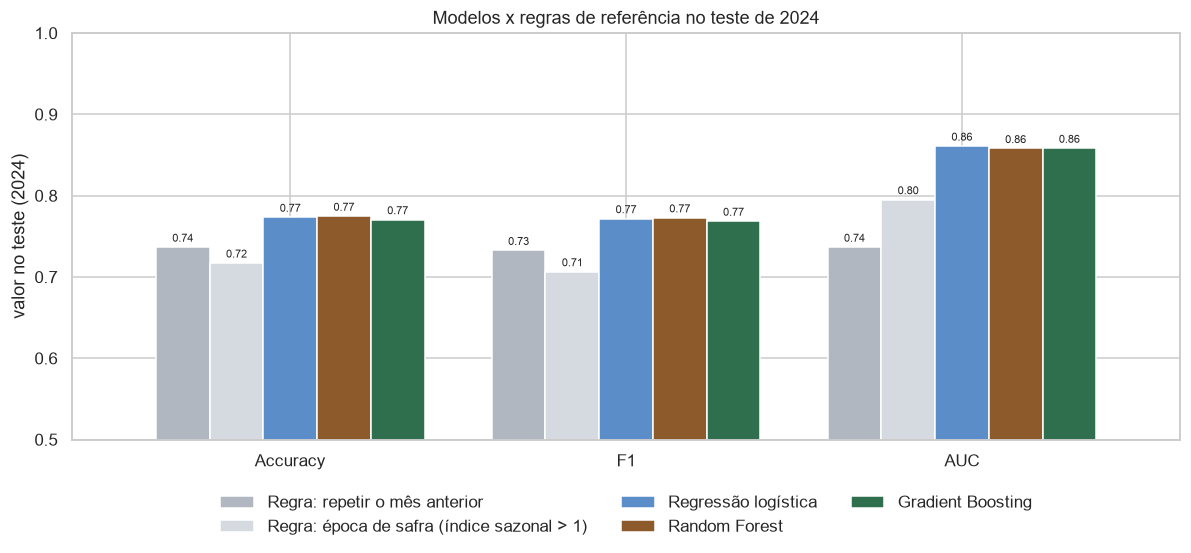

Modelo final: Regressão logística
Ganho sobre 'repetir o mês anterior': F1 +0.039 | Accuracy +0.037 | AUC +0.124


In [6]:
display(resultados[["tipo", "melhores_parametros", "f1_validacao", "accuracy", "f1", "precisao", "recall", "auc"]])

metricas_grafico = resultados[["accuracy", "f1", "auc"]].rename(columns={"accuracy": "Accuracy", "f1": "F1", "auc": "AUC"})
cores = ["#b0b7c0", "#d5dae0", "#5b8ec9", "#8c5a2b", "#2f6f4e"]
fig, eixo = plt.subplots(figsize=(13, 4.8))
metricas_grafico.T.plot.bar(ax=eixo, color=cores, rot=0, width=0.8)
eixo.set_ylim(0.5, 1.0)
eixo.set_ylabel("valor no teste (2024)")
eixo.set_title("Modelos x regras de referência no teste de 2024")
eixo.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
for barras in eixo.containers:
    eixo.bar_label(barras, fmt="%.2f", fontsize=7, padding=2)
salvar(fig, "14_comparacao_modelos")
plt.show()

regra = resultados.loc["Regra: repetir o mês anterior"]
final = resultados.loc[melhor]
print(f"Modelo final: {melhor}")
print(f"Ganho sobre 'repetir o mês anterior': F1 {final['f1'] - regra['f1']:+.3f} | "
      f"Accuracy {final['accuracy'] - regra['accuracy']:+.3f} | AUC {final['auc'] - regra['auc']:+.3f}")

- Os três modelos de aprendizado **superam as duas regras de referência** em Accuracy, F1 e AUC no teste de 2024.
- A regra "repetir o mês anterior" acerta bastante, porque a demanda tem persistência. A regra sazonal acerta menos no limiar fixo, mas tem AUC maior, porque o índice sazonal é contínuo e ordena melhor os casos. O modelo combina as duas fontes de informação, e o maior salto aparece justamente na **AUC**.
- Os três modelos ficam **próximos entre si** no teste: a qualidade das features pesa mais do que a escolha do algoritmo. O modelo final foi escolhido pela validação temporal, não pelo teste, então a pequena diferença entre eles no teste não altera a escolha.
- O F1 cai um pouco da validação (2023) para o teste (2024), mas as regras de referência, que não aprendem nada, caem na mesma proporção ou mais. Isso indica que 2024 é um ano um pouco mais difícil de prever, e não **sobreajuste** do modelo.

## 5. Modelo final: matriz de confusão e curva ROC

Modelo final: Regressão logística

               precision    recall  f1-score   support

baixa demanda      0.783     0.768     0.775      4064
 alta demanda      0.764     0.779     0.772      3926

     accuracy                          0.774      7990
    macro avg      0.774     0.774     0.774      7990
 weighted avg      0.774     0.774     0.774      7990



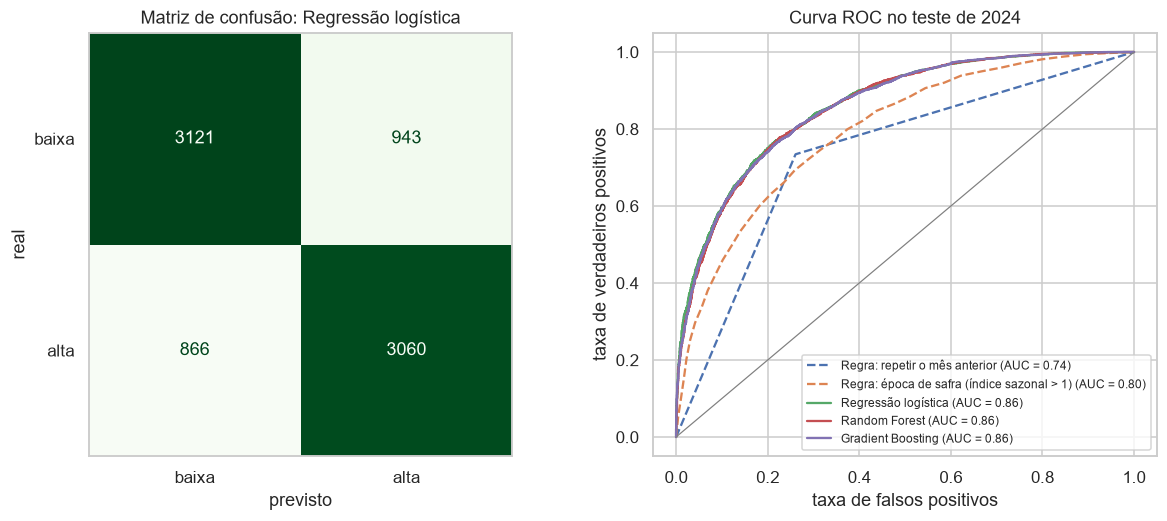

In [7]:
previsoes = tabela_previsoes(saida)
print(f"Modelo final: {melhor}\n")
print(classification_report(previsoes[ALVO], previsoes["previsto"], target_names=["baixa demanda", "alta demanda"], digits=3))

fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    previsoes[ALVO], previsoes["previsto"], display_labels=["baixa", "alta"], cmap="Greens", colorbar=False, ax=eixos[0]
)
eixos[0].set_title(f"Matriz de confusão: {melhor}")
eixos[0].grid(False)
eixos[0].set_xlabel("previsto")
eixos[0].set_ylabel("real")

for nome, (_, escore) in saida["previsoes"].items():
    fpr, tpr, _ = roc_curve(teste[ALVO], escore)
    eixos[1].plot(fpr, tpr, linestyle="--" if nome.startswith("Regra") else "-",
                  label=f"{nome} (AUC = {roc_auc_score(teste[ALVO], escore):.2f})")
eixos[1].set_xlabel("taxa de falsos positivos")
eixos[1].set_ylabel("taxa de verdadeiros positivos")
eixos[1].plot([0, 1], [0, 1], color="gray", linewidth=0.8)
eixos[1].set_title("Curva ROC no teste de 2024")
eixos[1].legend(fontsize=8, loc="lower right")
salvar(fig, "15_matriz_confusao_roc")
plt.show()

A matriz de confusão mostra que os erros se dividem entre os dois tipos (falsos positivos e falsos negativos) sem um viés forte para um lado, coerente com precisão e recall parecidos. Na curva ROC, as curvas dos modelos ficam acima das regras em praticamente toda a faixa: para qualquer nível tolerado de falsos alarmes, o modelo identifica mais meses de alta demanda.

## 6. Desempenho por produto e por mês

,registros,f1_modelo,f1_regra_mes_anterior,accuracy_modelo
nome,,,,
Açaí,2664,0.833,0.767,0.843
Castanha-do-pará,2664,0.779,0.745,0.773
Óleo de copaíba,2662,0.707,0.686,0.705


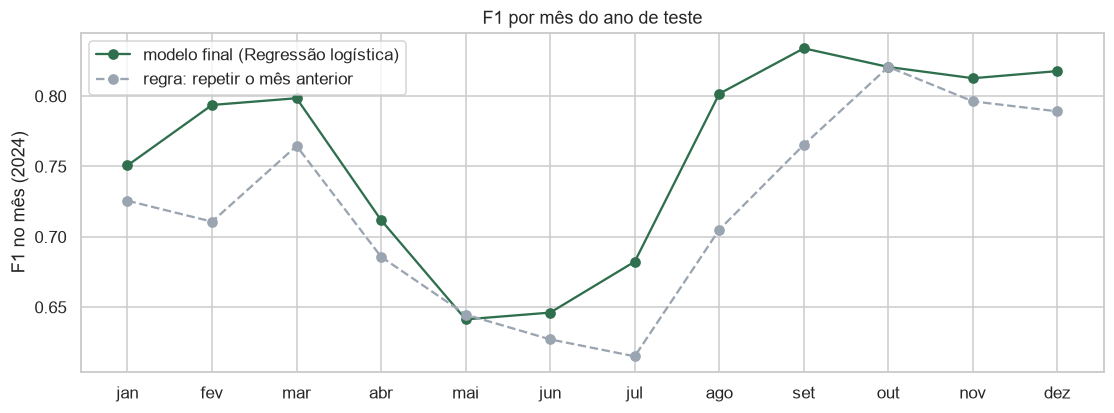

In [8]:
por_produto = metricas_por_grupo(previsoes, "nome").set_index("nome")
display(por_produto)

por_mes = metricas_por_grupo(previsoes, "mes").set_index("mes")
fig, eixo = plt.subplots(figsize=(12, 4))
eixo.plot(por_mes.index, por_mes["f1_modelo"], marker="o", color="#2f6f4e", label=f"modelo final ({melhor})")
eixo.plot(por_mes.index, por_mes["f1_regra_mes_anterior"], marker="o", linestyle="--", color="#9aa5b1",
          label="regra: repetir o mês anterior")
eixo.set_xticks(range(1, 13))
eixo.set_xticklabels(MESES)
eixo.set_ylabel("F1 no mês (2024)")
eixo.set_title("F1 por mês do ano de teste")
eixo.legend()
salvar(fig, "16_f1_por_mes")
plt.show()

- **Por produto:** o desempenho é melhor no **açaí**, cuja sazonalidade é a mais marcada, e menor no **óleo de copaíba**, cuja demanda varia pouco ao longo do ano e por isso depende mais de oscilações aleatórias, difíceis de antecipar. Nesse produto, o ganho sobre a regra também é o menor.
- **Por mês:** o modelo fica acima da regra em quase todos os meses, com empate técnico em maio e outubro. As maiores vantagens aparecem nos meses de virada da safra, como fevereiro, julho e agosto, quando a demanda muda de patamar e repetir o mês anterior deixa de funcionar. A seção 8 quantifica esse efeito.

## 7. Importância das features

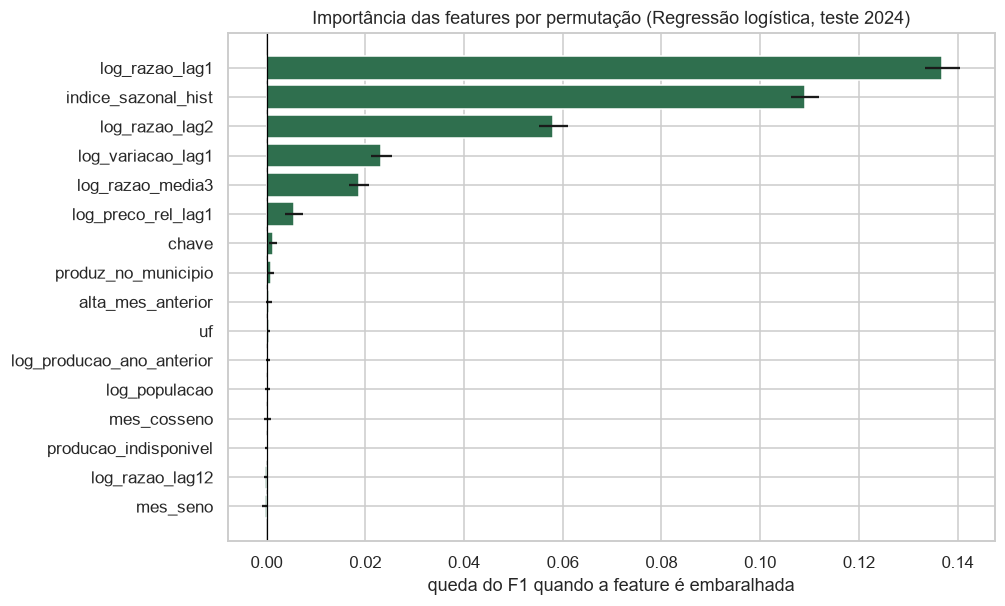

,feature,queda_f1_media,queda_f1_desvio
0,log_razao_lag1,0.137,0.004
1,indice_sazonal_hist,0.109,0.003
2,log_razao_lag2,0.058,0.003
3,log_variacao_lag1,0.023,0.002
4,log_razao_media3,0.019,0.002
5,log_preco_rel_lag1,0.006,0.002
6,chave,0.001,0.001
7,produz_no_municipio,0.001,0.001
8,alta_mes_anterior,0.000,0.001
9,uf,0.000,0.000


In [9]:
importancia = importancia_permutacao(saida["modelos"][melhor], teste)

fig, eixo = plt.subplots(figsize=(9, 6))
dados = importancia.iloc[::-1]
eixo.barh(dados["feature"], dados["queda_f1_media"], xerr=dados["queda_f1_desvio"], color="#2f6f4e")
eixo.axvline(0, color="black", linewidth=0.8)
eixo.set_xlabel("queda do F1 quando a feature é embaralhada")
eixo.set_title(f"Importância das features por permutação ({melhor}, teste 2024)")
salvar(fig, "17_importancia_features")
plt.show()

importancia

A importância por permutação mede quanto o F1 cai quando os valores de uma feature são embaralhados, quebrando a sua relação com o alvo.

- O modelo depende principalmente da **razão do mês anterior** (memória recente) e do **índice sazonal histórico** (sazonalidade), como a EDA e a Etapa 5 indicaram.
- Várias features relevantes na Etapa 5, como o alvo do mês anterior, a média dos últimos 3 meses e o preço, aparecem aqui com importância baixa. Isso não significa que sejam inúteis: elas carregam informação **redundante** com a razão do mês anterior. Quando uma delas é embaralhada, as outras compensam, e o F1 quase não cai. Essa é uma limitação conhecida da importância por permutação com features correlacionadas.
- Features com importância próxima de zero poderiam ser removidas numa versão mais enxuta do modelo, sem perda relevante.

## 8. De onde vem o ganho do modelo

In [10]:
analise = previsoes.merge(teste[["cod_ibge", "id_produto", "id_tempo", "alta_mes_anterior"]],
                          on=["cod_ibge", "id_produto", "id_tempo"])
analise["situacao"] = np.where(analise[ALVO] == analise["alta_mes_anterior"],
                               "manteve o estado do mês anterior", "mudou de estado")
analise["acertou_regra"] = (analise["previsto_regra_mes_anterior"] == analise[ALVO]).astype(int)

ganho = analise.groupby("situacao").agg(
    registros=(ALVO, "size"),
    acerto_regra=("acertou_regra", "mean"),
    acerto_modelo=("acertou", "mean"),
)
ganho["participação"] = ganho["registros"] / ganho["registros"].sum()
ganho

,registros,acerto_regra,acerto_modelo,participação
situacao,,,,
manteve o estado do mês anterior,5887,1.000,0.917,0.737
mudou de estado,2103,0.000,0.371,0.263


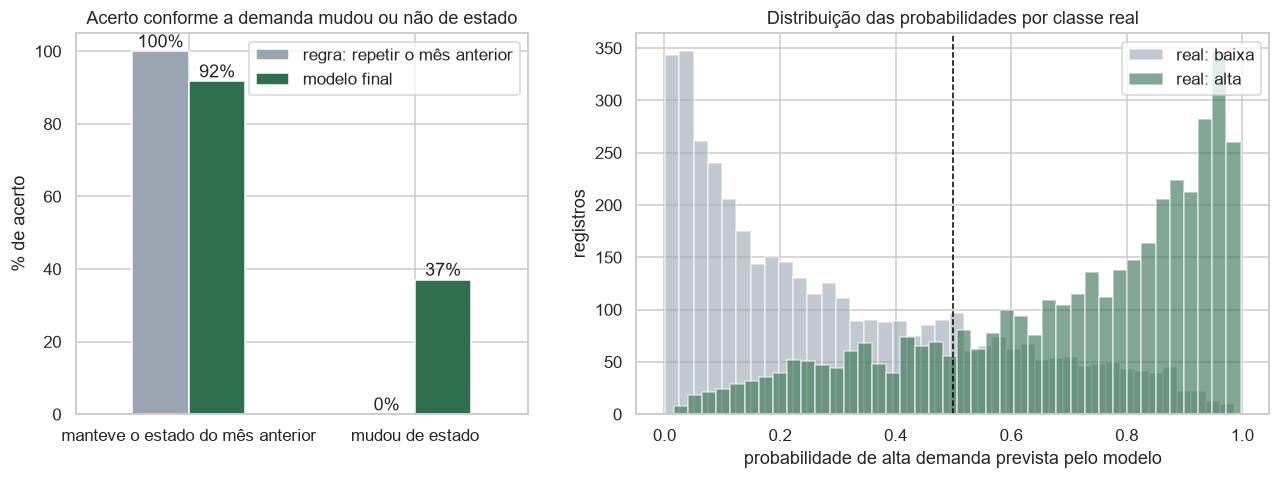

Registros com probabilidade entre 0,4 e 0,6: 15.2% | acerto nessa faixa: 54.2%
Registros com probabilidade fora dessa faixa: 84.8% | acerto: 81.5%


In [11]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
ganho[["acerto_regra", "acerto_modelo"]].mul(100).plot.bar(
    ax=eixos[0], color=["#9aa5b1", "#2f6f4e"], rot=0
)
eixos[0].set_ylabel("% de acerto")
eixos[0].set_xlabel("")
eixos[0].set_title("Acerto conforme a demanda mudou ou não de estado")
eixos[0].legend(["regra: repetir o mês anterior", "modelo final"], loc="upper right")
for barras in eixos[0].containers:
    eixos[0].bar_label(barras, fmt="%.0f%%")

for classe, cor, rotulo in [(0, "#9aa5b1", "real: baixa"), (1, "#2f6f4e", "real: alta")]:
    eixos[1].hist(analise.loc[analise[ALVO] == classe, "probabilidade_alta"], bins=40, alpha=0.6, color=cor, label=rotulo)
eixos[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
eixos[1].set_xlabel("probabilidade de alta demanda prevista pelo modelo")
eixos[1].set_ylabel("registros")
eixos[1].set_title("Distribuição das probabilidades por classe real")
eixos[1].legend()
salvar(fig, "18_ganho_e_probabilidades")
plt.show()

incertos = analise["probabilidade_alta"].between(0.4, 0.6)
print(f"Registros com probabilidade entre 0,4 e 0,6: {incertos.mean():.1%} | acerto nessa faixa: {analise.loc[incertos, 'acertou'].mean():.1%}")
print(f"Registros com probabilidade fora dessa faixa: {(~incertos).mean():.1%} | acerto: {analise.loc[~incertos, 'acertou'].mean():.1%}")

- Por definição, a regra "repetir o mês anterior" **erra todas as mudanças de estado**. O modelo acerta uma parte relevante dessas viradas, porque combina a memória recente com a sazonalidade e o preço. É aí que está o seu ganho.
- Quando a demanda mantém o estado, a regra acerta 100% por definição, e o modelo acerta um pouco menos: ele troca alguns acertos fáceis por acertos nas viradas, com saldo positivo no total.
- As probabilidades são informativas: quando o modelo está confiante (longe de 0,5), o acerto é bem maior do que na faixa de incerteza. Na prática, isso permite agir com mais segurança nos casos de alta probabilidade e tratar os casos intermediários com cautela.
- Parte dos erros é inevitável: as vendas têm uma variação aleatória mês a mês que nenhuma informação do passado consegue antecipar. Por isso não se deve esperar acerto próximo de 100%.

## 9. Modelo salvo e reprodutibilidade

In [12]:
pacote = salvar_modelo(saida)
recarregado = carregar_modelo()

previsto_recarregado = recarregado["modelo"].predict(teste[recarregado["features"]])
print(f"Arquivo: {config.MODELS_DIR / 'modelo_alta_demanda.pkl'}")
print("Previsões idênticas após recarregar o .pkl:", bool((previsto_recarregado == previsoes["previsto"].to_numpy()).all()))
pd.Series({k: v for k, v in recarregado.items() if k not in ("modelo", "features")}, name="metadados").to_frame()

Arquivo: C:\p15-projeto-integrador\models\modelo_alta_demanda.pkl
Previsões idênticas após recarregar o .pkl: True


,metadados
nome,Regressão logística
alvo,alta_demanda
parametros,C=10.0
periodo_treino,jan/2023 a dez/2023
metricas_teste_2024,"{'accuracy': 0.7735919899874844, 'f1': 0.771850170261067, 'precisao': 0.7644266799900075, 'recall': 0.7794192562404483, 'auc': 0.8610869115045668}"
treinado_em,2026-10-03T14:37:22
versao_scikit_learn,1.9.1


O arquivo `.pkl` guarda o pipeline completo (pré-processamento e modelo) junto com os metadados: features esperadas, parâmetros, período de treino, métricas no teste e versão do scikit-learn. Ao ser recarregado, ele reproduz exatamente as mesmas previsões. O script `python -m src.train` executa todo este processo pelo terminal e grava as métricas e as previsões também no PostgreSQL (`ml.metricas_modelos` e `ml.previsoes_teste`).

## 10. Conclusões

- **O pipeline responde à pergunta de negócio:** com informação disponível no início do mês, o modelo prevê se cada município terá alta demanda de cada produto, com desempenho no teste de 2024 superior ao das regras de referência (valores na seção 4).
- **A avaliação é honesta:** divisão temporal, seleção feita só com dados de 2023, teste usado uma única vez e features sem vazamento (Etapa 5). O desempenho parecido entre validação e teste indica boa generalização.
- **O ganho está nas viradas de demanda:** o modelo antecipa parte das mudanças de estado que a regra simples sempre erra, o que tem valor prático para planejar estoque e logística na entrada e na saída da safra.
- **Features importam mais que o algoritmo:** os três modelos ficaram próximos; memória recente, sazonalidade e preço explicam a maior parte do desempenho.

**Limitações**

- As vendas são simuladas; as relações aprendidas refletem as regras da simulação, ancoradas em dados reais do IBGE. Com dados reais de cooperativas, o mesmo pipeline pode ser reaplicado.
- O teste cobre um único ano (2024). Mais anos de histórico permitiriam avaliar a estabilidade do modelo em safras atípicas.
- O limiar de decisão foi mantido em 0,5. Se faltar produto custar mais do que sobrar, o limiar pode ser reduzido para priorizar o recall.

**Próximos passos:** ajustar o limiar ao custo de cada tipo de erro, incluir variáveis climáticas (como chuvas, que influenciam a safra) e disponibilizar o modelo por uma API, como no bônus do P14.